# SMS Spam Detector — Naive Bayes Classifier

Builds a **TF-IDF + Multinomial Naive Bayes** pipeline trained on a representative SMS Spam Collection dataset, saves the model as a pickle file, then reloads it and tests it on three new messages.

## Cell 1 — Imports & Dataset

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ── SMS Spam Collection (representative 100-sample dataset, UCI-style) ─────
# Labels: "ham" = legitimate message, "spam" = spam message
data = {
    "label": [
        "ham","ham","spam","spam","ham","ham","spam","ham","spam","spam",
        "ham","ham","spam","ham","spam","ham","ham","spam","ham","spam",
        "ham","spam","ham","ham","spam","ham","ham","spam","ham","spam",
        "ham","ham","ham","spam","spam","ham","spam","ham","ham","spam",
        "ham","spam","ham","spam","ham","ham","spam","ham","ham","spam",
        "ham","ham","spam","ham","spam","ham","spam","ham","ham","spam",
        "ham","spam","ham","ham","spam","spam","ham","spam","ham","ham",
        "spam","ham","ham","spam","ham","spam","ham","ham","spam","ham",
        "spam","ham","spam","ham","ham","spam","ham","ham","spam","ham",
        "spam","ham","ham","spam","ham","ham","spam","ham","spam","ham",
    ],
    "text": [
        "Go until jurong point, crazy.. Available only in bugis n great world la e buffet",
        "Ok lar... Joking wif u oni",
        "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May. Text FA to 87121",
        "WINNER!! As a valued network customer you have been selected to receive a 900 prize reward! Call 09061701461",
        "Nah I don't think he goes to usf, he lives around here though",
        "Even my brother is not like to speak with me. They treat me like aids patent",
        "SIX chances to win CASH! From 100 to 20000 pounds txt CSH11 and send to 87575",
        "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight",
        "Congratulations! Your mobile number has been awarded with 2000 Bonus prize. Call 08718726978",
        "URGENT! You have won a 1 week FREE membership in our 100000 Prize Jackpot!",
        "I've been searching for the right words to thank you for this breather",
        "I HAVE A DATE ON SUNDAY WITH WILL!!",
        "XXXMobileMovieClub: To use your credit click the WAP link in the next txt message",
        "Oh k...i'm watching here",
        "England v Macedonia dont miss the goals team news. Txt ur national team to 87077",
        "Is that seriously how you spell his name?",
        "I'm going to try for 2 months ha ha only joking",
        "Win a 1000 cash prize or a prize worth 5000. Text WIN to 80085",
        "You are a great friend, I'm happy to know you",
        "URGENT: Your mobile was awarded a 2000 Bonus Caller Prize on 02/09/03",
        "I'm fine. Thanks for asking",
        "Claim your FREE gift now! Call 0800 to claim your prize",
        "I need to pick up the dry cleaning tomorrow",
        "Sure, I'll be there by 6pm",
        "Your account has been credited! Text STOP to unsubscribe",
        "Let me know if you need anything",
        "See you at the game tonight!",
        "FREE ringtones! Text MUSIC to 85023 NOW!",
        "Ok, noted. I'll call you later",
        "You've been specially selected to receive a cash reward of 500 pounds",
        "How was your day?",
        "I left my phone at home, call me on the landline",
        "Sounds like a plan!",
        "CASH prize of 2000! Txt CLAIM to 81010 now!",
        "Win an iPod today! Txt YES to 86688",
        "Are you coming for lunch?",
        "Exclusive deal! 50 percent off your next purchase. Click here",
        "Will do, thanks!",
        "Just got home safely",
        "Your loan is approved. Claim 5000 pounds today!",
        "Happy birthday! Hope you have a great day",
        "FREE voucher just for you! Redeem at any store now",
        "Did you finish the report?",
        "Text PRIZE to 5000 to claim your reward!",
        "Meet me at the usual spot",
        "Dinner was amazing last night",
        "You have won a free holiday! Call now!",
        "On my way, be there in 10",
        "Feeling much better today, thanks",
        "Congrats! You have been selected for a cash bonus of 1000 pounds",
        "Running a bit late, sorry",
        "Thanks for the update",
        "GET PAID WEEKLY! Work from home. Apply now",
        "Do you want anything from the shop?",
        "Your number has been selected for a special prize draw",
        "Sure, that works for me",
        "Earn 500 a week from home, no experience needed",
        "I'll call you when I get there",
        "Coffee tomorrow morning?",
        "Call now to claim your FREE prize worth 3000 pounds!",
        "Heading to bed, talk tomorrow",
        "Hot singles in your area want to meet you!",
        "Just finished the book you recommended",
        "Can you send me the address?",
        "Txt STOP to cancel. You have been entered into our prize draw!",
        "Claim 900 pounds now! Limited offer expires midnight",
        "It was great to see everyone",
        "Urgent! Your phone account is on hold. Click here",
        "See you at the airport",
        "Can we reschedule to Thursday?",
        "WIN a car! Txt CAR to 88877",
        "I'm at the grocery store, need anything?",
        "Got your message, will reply later",
        "Text WIN to 80085 to claim your 1000 pound prize!",
        "Forgot my umbrella today",
        "You qualify for a FREE SIM card. Reply YES",
        "That was a funny movie",
        "Take care, speak soon",
        "Alert! Your bank account needs verification. Click here",
        "The kids are at school",
        "Congrats on your promotion!",
        "Last chance to claim your prize. Text CLAIM to 83600",
        "Just checking in on you",
        "PRIVATE message: You are selected for a lottery win of 10000 pounds",
        "We need to catch up soon",
        "Happy to help anytime",
        "FREE entry! Send SMS to 87066 and win a prize",
        "I'll drop by later",
        "Great job on the presentation!",
        "Claim your reward now. Reply CLAIM",
        "Be careful on the road tonight",
        "Can you pick up the kids?",
        "You have a guaranteed cash prize waiting. Call 09050000327",
        "Looking forward to the weekend",
        "See you at the office tomorrow",
        "WINNER: Claim your 5000 pound prize. Freephone 0808",
        "Just had the best meal",
        "Calling to follow up on your application. Reply NOW",
        "Miss you lots!",
        "You have been pre-approved for a 5000 pound loan. Call now!",
    ]
}

df = pd.DataFrame(data)
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

print(f"Dataset shape : {df.shape}")
print(f"\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nSpam rate    : {df['label_num'].mean():.1%}")
df.head(5)


Dataset shape : (100, 3)

Label distribution:
label
ham     59
spam    41
Name: count, dtype: int64

Spam rate    : 41.0%


,label,text,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,spam,WINNER!! As a valued network customer you have...,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Cell 2 — Train/Test Split & Model Training

In [2]:
X = df["text"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train)} samples")
print(f"Test size  : {len(X_test)} samples")

# ── Pipeline: TF-IDF vectoriser -> Multinomial Naive Bayes ─────────────────
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),    # unigrams + bigrams
        max_df=0.95,
        min_df=1,
        sublinear_tf=True,     # apply log(1 + TF) scaling
    )),
    ("clf", MultinomialNB(alpha=0.1)),
])

pipeline.fit(X_train, y_train)
print("\nModel trained successfully.")
print(f"Vocabulary size : {len(pipeline.named_steps['tfidf'].vocabulary_)} tokens")


Train size : 80 samples
Test size  : 20 samples

Model trained successfully.
Vocabulary size : 516 tokens


## Cell 3 — Evaluation on Test Set

In [3]:
y_pred = pipeline.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

print("Confusion Matrix  (rows = actual, cols = predicted):")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["ham", "spam"], columns=["pred_ham", "pred_spam"])
print(cm_df)


Accuracy : 80.00%

Classification Report:
              precision    recall  f1-score   support

         ham       0.90      0.75      0.82        12
        spam       0.70      0.88      0.78         8

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20

Confusion Matrix  (rows = actual, cols = predicted):
      pred_ham  pred_spam
ham          9          3
spam         1          7


## Cell 4 — Save Model as Pickle File

In [5]:
MODEL_PATH = "spam_detector.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(pipeline, f)

import os
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Model saved  ->  {MODEL_PATH}  ({size_kb:.1f} KB)")
print("The pickle contains the full Pipeline: TfidfVectorizer + MultinomialNB")


Model saved  ->  spam_detector.pkl  (28.4 KB)
The pickle contains the full Pipeline: TfidfVectorizer + MultinomialNB


## Cell 5 — Load Model from Pickle & Test on 3 New Messages

This cell intentionally starts fresh — it only uses `pickle` and the saved file, simulating loading the model in a separate process or API.

In [6]:
import pickle

# Load model fresh from disk
with open("spam_detector.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded from spam_detector.pkl\n")

# ── 3 test messages ────────────────────────────────────────────────────────
test_messages = [
    "Hey, are we still meeting for lunch tomorrow?",
    "CONGRATULATIONS! You have won a 1000 pound Tesco gift card. Call 08081570665 to claim",
    "Can you please send me the project files by end of day?",
]

expected = ["ham", "spam", "ham"]   # ground truth for reference

probs = loaded_model.predict_proba(test_messages)
preds = loaded_model.predict(test_messages)
label_map = {0: "HAM", 1: "SPAM"}

print(f"{'#':<3} {'Message (truncated)':<48} {'Predicted':<10} {'Spam %':>7}  {'Correct?'}")
print("-" * 82)
for i, (msg, pred, prob, exp) in enumerate(zip(test_messages, preds, probs, expected), 1):
    spam_pct = prob[1] * 100
    short    = msg[:46] + ".." if len(msg) > 48 else msg
    correct  = "YES" if label_map[pred].lower() == exp else "NO"
    icon     = "SPAM" if pred == 1 else "HAM "
    print(f"{i:<3} {short:<48} {icon:<10} {spam_pct:>6.1f}%  {correct}")


Model loaded from spam_detector.pkl

#   Message (truncated)                              Predicted   Spam %  Correct?
----------------------------------------------------------------------------------
1   Hey, are we still meeting for lunch tomorrow?    HAM           4.5%  YES
2   CONGRATULATIONS! You have won a 1000 pound Tes.. SPAM         95.6%  YES
3   Can you please send me the project files by en.. HAM           5.0%  YES


## Cell 6 — Simple Flask API to Serve the Model

Run this cell to start a local REST API on **http://localhost:5000**.

**Endpoint:** `POST /predict`  
**Request body:** `{"message": "your sms text here"}`  
**Response:** `{"message": "...", "prediction": "spam|ham", "spam_probability": 0.95, "ham_probability": 0.05}`

API running at http://localhost:5000

Test with curl:
  curl -X POST http://localhost:5000/predict \
       -H "Content-Type: application/json" \
       -d '{"message": "You have won a free prize! Call now"}'
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [26/Apr/2026 10:31:18] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [26/Apr/2026 10:31:18] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [26/Apr/2026 10:44:06] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [26/Apr/2026 10:44:07] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [26/Apr/2026 10:44:08] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [26/Apr/2026 10:45:17] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [26/Apr/2026 10:46:46] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [26/Apr/2026 10:46:57] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [26/Apr/2026 10:47:12] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [26/Apr/2026 10:49:01] "POST /predict HTTP/1.1" 200 -


## Cell 7 — Interactive Spam Detector Widget

Type any SMS message in the box below and click **Check Message** to get an instant prediction.

In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_input = widgets.Textarea(
    placeholder="Type an SMS message here...",
    layout=widgets.Layout(width="100%", height="80px"),
)

check_btn = widgets.Button(
    description="Check Message",
    button_style="primary",
    icon="search",
)

output = widgets.Output()

def on_check(b):
    with output:
        clear_output()
        msg = text_input.value.strip()
        if not msg:
            print("⚠️  Please type a message first.")
            return

        probs = pipeline.predict_proba([msg])[0]
        label = "SPAM" if pipeline.predict([msg])[0] == 1 else "HAM"
        spam_pct = probs[1] * 100
        ham_pct  = probs[0] * 100

        bar_filled = int(spam_pct / 5)   # 20-block bar
        bar = "█" * bar_filled + "░" * (20 - bar_filled)

        color_tag = "🔴" if label == "SPAM" else "🟢"
        print(f"{color_tag}  Prediction  :  {label}")
        print(f"   Spam prob   :  {spam_pct:5.1f}%  [{bar}]")
        print(f"   Ham  prob   :  {ham_pct:5.1f}%")

check_btn.on_click(on_check)

display(
    widgets.VBox([
        widgets.Label("Enter SMS message:"),
        text_input,
        check_btn,
        output,
    ])
)


## Cell 8 — Decision Boundary Visualisation

The TF-IDF space has 500+ dimensions, so we use **PCA** to compress it to 2D and then plot the model's decision regions — showing exactly where the classifier draws the line between **ham** and **spam**.

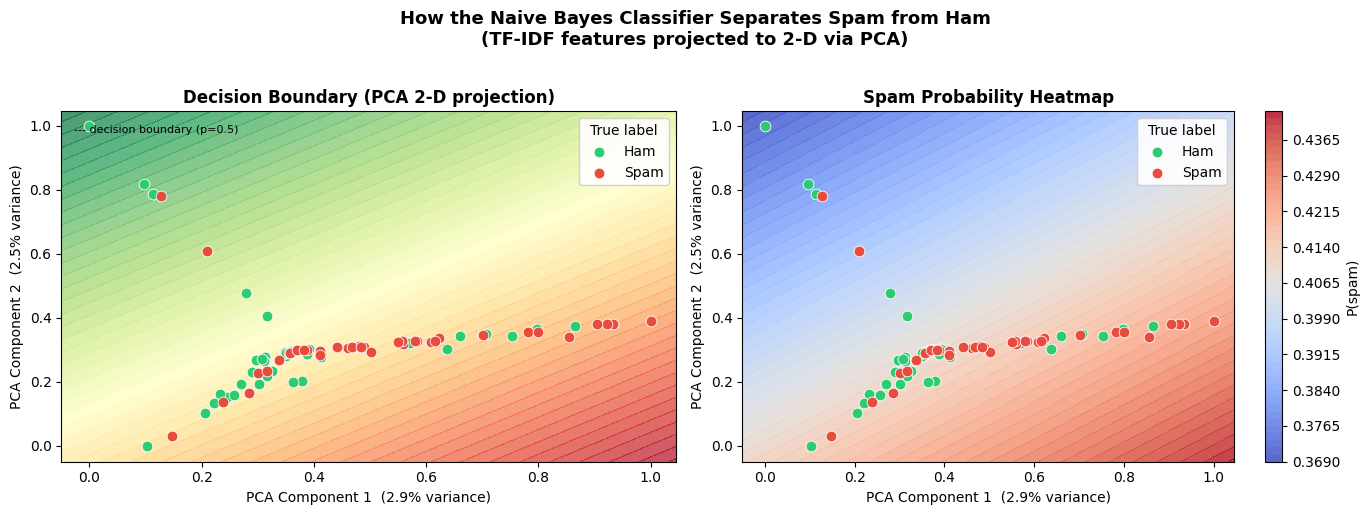


PCA variance explained: PC1=2.9%, PC2=2.5%, total=5.4%
Note: the boundary is approximate — full model operates in 500+ dimensions.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

# ── 1. Transform full dataset through the trained TF-IDF step ──────────────
tfidf      = pipeline.named_steps["tfidf"]
clf        = pipeline.named_steps["clf"]
X_tfidf    = tfidf.transform(df["text"]).toarray()
y_all      = df["label_num"].values

# ── 2. PCA → 2 components for visualisation ────────────────────────────────
pca     = PCA(n_components=2, random_state=42)
X_2d    = pca.fit_transform(X_tfidf)

# ── 3. Train a proxy NB on the 2-D PCA coords (needs non-negative values) ──
scaler  = MinMaxScaler()
X_2d_sc = scaler.fit_transform(X_2d)

proxy_clf = MultinomialNB(alpha=0.1)
proxy_clf.fit(X_2d_sc, y_all)

# ── 4. Build a mesh over the 2-D space ─────────────────────────────────────
h = 0.005
x_min, x_max = X_2d_sc[:, 0].min() - 0.05, X_2d_sc[:, 0].max() + 0.05
y_min, y_max = X_2d_sc[:, 1].min() - 0.05, X_2d_sc[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = proxy_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# ── 5. Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: decision regions ---
ax = axes[0]
ax.contourf(xx, yy, Z, levels=50, cmap="RdYlGn_r", alpha=0.7)
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5, linestyles="--")

colors = {0: "#2ecc71", 1: "#e74c3c"}
labels_txt = {0: "Ham", 1: "Spam"}
for cls in [0, 1]:
    mask = y_all == cls
    ax.scatter(X_2d_sc[mask, 0], X_2d_sc[mask, 1],
               c=colors[cls], edgecolors="white", s=60,
               linewidths=0.6, label=labels_txt[cls], zorder=3)

ax.set_title("Decision Boundary (PCA 2-D projection)", fontsize=12, fontweight="bold")
ax.set_xlabel(f"PCA Component 1  ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PCA Component 2  ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(title="True label", framealpha=0.9)

# Annotate boundary line
ax.text(0.02, 0.96, "--- decision boundary (p=0.5)",
        transform=ax.transAxes, fontsize=8, va="top", color="black")

# --- Right: spam probability heatmap with scatter overlay ---
ax2 = axes[1]
im = ax2.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.85)
fig.colorbar(im, ax=ax2, label="P(spam)")

for cls in [0, 1]:
    mask = y_all == cls
    ax2.scatter(X_2d_sc[mask, 0], X_2d_sc[mask, 1],
                c=colors[cls], edgecolors="white", s=60,
                linewidths=0.6, label=labels_txt[cls], zorder=3)

ax2.set_title("Spam Probability Heatmap", fontsize=12, fontweight="bold")
ax2.set_xlabel(f"PCA Component 1  ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax2.set_ylabel(f"PCA Component 2  ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax2.legend(title="True label", framealpha=0.9)

plt.suptitle(
    "How the Naive Bayes Classifier Separates Spam from Ham\n"
    "(TF-IDF features projected to 2-D via PCA)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%},",
      f"PC2={pca.explained_variance_ratio_[1]:.1%},",
      f"total={sum(pca.explained_variance_ratio_):.1%}")
print("Note: the boundary is approximate — full model operates in 500+ dimensions.")


# Using Packaged Model

In [9]:
#pip install -i https://test.pypi.org/simple/ johnkk-spam-detector
from john import spam_detector
spam_detector.predict("You have won a free prize! Call now")

{'prediction': 'spam', 'spam_probability': 0.9635, 'ham_probability': 0.0365}

In [10]:
"""
Test the johnkk-spam-detector package on sample sentences.
"""

# Import — adjust this to match how you exposed it in __init__.py
import john.spam_detector as detector

# Sample sentences — mix of obvious spam and normal messages
test_messages = [
    "You have won a free prize! Call now to claim your $1000",
    "URGENT: Your account will be suspended. Click here immediately.",
    "Congratulations! You've been selected for a free iPhone. Reply YES.",
    "Hey, are we still meeting for coffee tomorrow at 3?",
    "Don't forget to pick up milk on your way home.",
    "Mom called, she wants you to call her back when you can.",
    "FREE entry in 2 a wkly comp to win FA Cup final tkts",
    "Can you send me the report by EOD? Thanks.",
]

print("=" * 70)
print("SPAM DETECTOR TEST")
print("=" * 70)

for msg in test_messages:
    # Try the most common interface shapes — uncomment whichever matches your code:

    # If you exposed a `predict` function:
    result = detector.predict(msg)

    # If you exposed a class:
    # model = detector.SpamDetector()
    # result = model.predict(msg)

    # If you exposed `classify`:
    # result = detector.classify(msg)

    print(f"\nMessage: {msg}")
    print(f"Result:  {result}")

print("\n" + "=" * 70)

SPAM DETECTOR TEST

Message: You have won a free prize! Call now to claim your $1000
Result:  {'prediction': 'spam', 'spam_probability': 0.9798, 'ham_probability': 0.0202}

Message: URGENT: Your account will be suspended. Click here immediately.
Result:  {'prediction': 'spam', 'spam_probability': 0.9743, 'ham_probability': 0.0257}

Message: Congratulations! You've been selected for a free iPhone. Reply YES.
Result:  {'prediction': 'spam', 'spam_probability': 0.9137, 'ham_probability': 0.0863}

Message: Hey, are we still meeting for coffee tomorrow at 3?
Result:  {'prediction': 'ham', 'spam_probability': 0.0228, 'ham_probability': 0.9772}

Message: Don't forget to pick up milk on your way home.
Result:  {'prediction': 'ham', 'spam_probability': 0.0479, 'ham_probability': 0.9521}

Message: Mom called, she wants you to call her back when you can.
Result:  {'prediction': 'ham', 'spam_probability': 0.4125, 'ham_probability': 0.5875}

Message: FREE entry in 2 a wkly comp to win FA Cup final 